In [ ]:
!pip install opendatasets -q

import opendatasets as od
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt
import numpy as np

print("TF version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

TF version: 2.20.0


In [ ]:
od.download("https://www.kaggle.com/datasets/ashishmotwani/tomato")
print("Download complete")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hege00
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato


100%|██████████| 1.37G/1.37G [00:38<00:00, 38.0MB/s]



Download complete


## 1. Dataset loading

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = "tomato/train"
VALID_DIR = "tomato/valid"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

base_val_ds_val = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.5,
    subset="training",
    seed=42
)

base_val_ds_test = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.5,
    subset="validation",
    seed=42
)

val_ds  = base_val_ds_val.cache().prefetch(AUTOTUNE)
test_ds = base_val_ds_test.cache().prefetch(AUTOTUNE)

class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)

print("--- DATASET SPLIT ---")
print(f"Train batches : {tf.data.experimental.cardinality(train_ds_raw).numpy()}")
print(f"Val   batches : {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test  batches : {tf.data.experimental.cardinality(test_ds).numpy()}")
print(f"\nClasses ({NUM_CLASSES}):")
for i, n in enumerate(class_names):
    print(f"  {i:2d}: {n}")

Found 25851 files belonging to 11 classes.
Found 6683 files belonging to 11 classes.
Using 3342 files for training.
Found 6683 files belonging to 11 classes.
Using 3341 files for validation.
--- DATASET SPLIT ---
Train batches : 808
Val   batches : 105
Test  batches : 105

Classes (11):
   0: Bacterial_spot
   1: Early_blight
   2: Late_blight
   3: Leaf_Mold
   4: Septoria_leaf_spot
   5: Spider_mites Two-spotted_spider_mite
   6: Target_Spot
   7: Tomato_Yellow_Leaf_Curl_Virus
   8: Tomato_mosaic_virus
   9: healthy
  10: powdery_mildew


In [ ]:
def verify_dataset(ds, name):
    class_counts = {}
    total_images = 0

    for images, labels in ds:
        total_images += images.shape[0]
        for label in labels.numpy():
            class_counts[class_names[label]] = class_counts.get(class_names[label], 0) + 1

    print(f"\n--- {name} ---")
    print(f"Total images : {total_images}")
    print(f"Classes found: {len(class_counts)}/{NUM_CLASSES}")
    for cls in class_names:
        count = class_counts.get(cls, 0)
        flag = "⚠️  MISSING" if count == 0 else ""
        print(f"  {cls:<40} {count:>5}  {flag}")

verify_dataset(val_ds,  "Validation Set")
verify_dataset(test_ds, "Test Set")
verify_dataset(train_ds_raw, "Train Set")


--- Validation Set ---
Total images : 3342
Classes found: 11/11
  Bacterial_spot                             387  
  Early_blight                               313  
  Late_blight                                388  
  Leaf_Mold                                  368  
  Septoria_leaf_spot                         385  
  Spider_mites Two-spotted_spider_mite       227  
  Target_Spot                                224  
  Tomato_Yellow_Leaf_Curl_Virus              247  
  Tomato_mosaic_virus                        289  
  healthy                                    389  
  powdery_mildew                             125  

--- Test Set ---
Total images : 3341
Classes found: 11/11
  Bacterial_spot                             345  
  Early_blight                               330  
  Late_blight                                404  
  Leaf_Mold                                  371  
  Septoria_leaf_spot                         361  
  Spider_mites Two-spotted_spider_mite       208  
  Target_

## 2. Augmentation pipeline

RandomFlip / Rotation / Zoom

RandomBrightness

RandomContrast

RandomTranslation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

# EfficientNetB0 has its own built-in preprocessing
train_ds = (train_ds_raw
            .map(lambda x, y: (data_augmentation(x, training=True), y),
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds  = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

## 3. Model — EfficientNetB0 with transfer learning

**Two-phase training strategy:**

1. **Phase 1** — freeze the entire base; only train the new head. The base weights are fragile at first; training the head alone lets it stabilise before we touch the base.
2. **Phase 2** — unfreeze the top 30 layers of the base and fine-tune with a small learning rate. The top layers learn disease-specific features while the bottom layers (generic edges) stay mostly frozen.

In [ ]:
def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )
    base_model.trainable = False

    x = layers.Rescaling(1./255)(base_model.output)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs), base_model

model, base_model = build_model(NUM_CLASSES)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_4[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,385,454 (16.73 MB)

 Trainable params: 333,323 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 4. Phase 1 - train the head only

We use a relatively high learning rate here because only the new dense layers are updating; the pretrained weights are frozen and safe.

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Phase 1 compile

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Phase 1: training head only (base frozen)")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Phase 1: training head only (base frozen)
Epoch 1/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 142s 128ms/step - accuracy: 0.6508 - loss: 1.0733 - val_accuracy: 0.7516 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 2/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.7754 - loss: 0.6686 - val_accuracy: 0.7890 - val_loss: 0.5948 - learning_rate: 0.0010
Epoch 3/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - accuracy: 0.8070 - loss: 0.5683 - val_accuracy: 0.8016 - val_loss: 0.5550 - learning_rate: 0.0010
Epoch 4/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - accuracy: 0.8252 - loss: 0.5139 - val_accuracy: 0.8202 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 5/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.8374 - loss: 0.4696 - val_accuracy: 0.8402 - val_loss: 0.4463 - learning_rate: 0.0010
Epoch 6/10
808/808 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - accuracy: 0.8487 - loss: 0.4381 - val_accuracy: 0.8393 - val_loss: 0.4468 - learning_rate: 0.0010
Epoch 7/10
808/808 ━━━━━━━━━━━━━

## 5. Phase 2 - unfreeze and fine-tune

In [ ]:
base_model.trainable = True

total_layers = len(base_model.layers)
fine_tune_from = total_layers - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning {trainable_count} of {total_layers} base layers")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

print("\nPhase 2: fine-tuning top 30 layers")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping_phase2, reduce_lr]
)

Fine-tuning 30 of 238 base layers

Phase 2: fine-tuning top 30 layers
Epoch 1/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 129s 117ms/step - accuracy: 0.8577 - loss: 0.4127 - val_accuracy: 0.8944 - val_loss: 0.2973 - learning_rate: 1.0000e-04
Epoch 2/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - accuracy: 0.9087 - loss: 0.2696 - val_accuracy: 0.9126 - val_loss: 0.2325 - learning_rate: 1.0000e-04
Epoch 3/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.9229 - loss: 0.2272 - val_accuracy: 0.9354 - val_loss: 0.1745 - learning_rate: 1.0000e-04
Epoch 4/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.9356 - loss: 0.1845 - val_accuracy: 0.9428 - val_loss: 0.1572 - learning_rate: 1.0000e-04
Epoch 5/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 64s 79ms/step - accuracy: 0.9443 - loss: 0.1638 - val_accuracy: 0.9545 - val_loss: 0.1375 - learning_rate: 1.0000e-04
Epoch 6/15
808/808 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - accuracy: 0.9477 - loss: 0.1503 - val_accuracy: 0.9590 - val_loss: 0.1290 - learni

## 6. Results - combined training curves

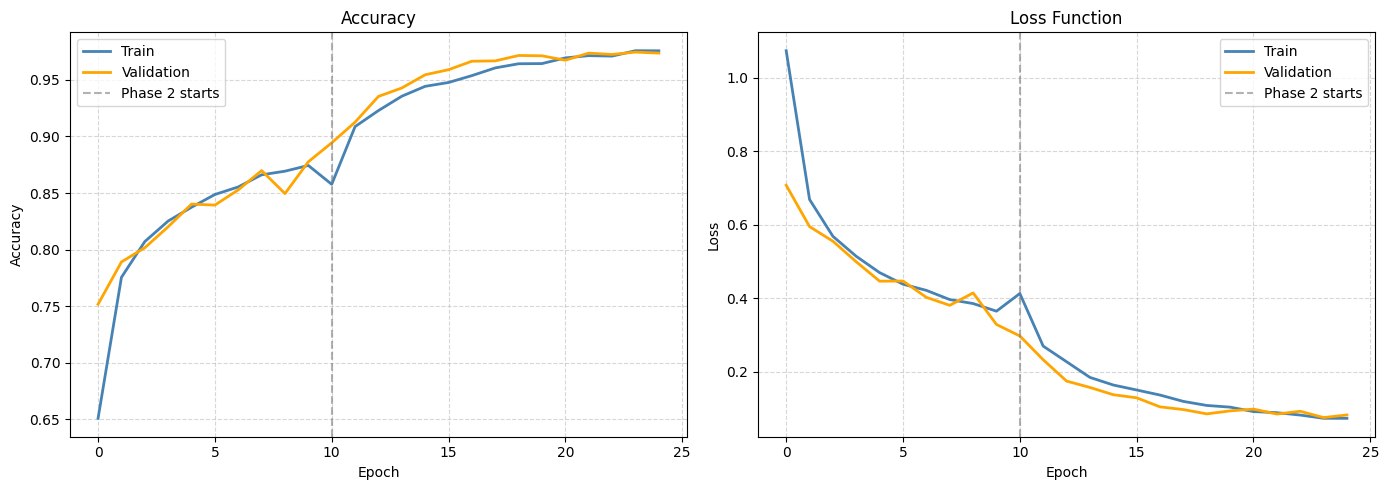


Best validation accuracy: 0.9746 (97.5%)


In [ ]:
def plot_history(h1, h2):
    acc1  = h1.history["accuracy"]
    vacc1 = h1.history["val_accuracy"]
    acc2  = h2.history["accuracy"]
    vacc2 = h2.history["val_accuracy"]
    loss1  = h1.history["loss"]
    vloss1 = h1.history["val_loss"]
    loss2  = h2.history["loss"]
    vloss2 = h2.history["val_loss"]

    acc   = acc1 + acc2
    vacc  = vacc1 + vacc2
    loss  = loss1 + loss2
    vloss = vloss1 + vloss2
    epochs = range(len(acc))
    split  = len(acc1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, y, vy, title, ylabel in [
        (axes[0], acc,  vacc,  "Accuracy",     "Accuracy"),
        (axes[1], loss, vloss, "Loss Function", "Loss"),
    ]:
        ax.plot(epochs, y,  label="Train",      color="steelblue", linewidth=2)
        ax.plot(epochs, vy, label="Validation", color="orange",    linewidth=2)
        ax.axvline(split, color="gray", linestyle="--", alpha=0.6, label="Phase 2 starts")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best_val = max(vacc)
    print(f"\nBest validation accuracy: {best_val:.4f} ({best_val*100:.1f}%)")

plot_history(history_phase1, history_phase2)

## 7. Evaluation on test set

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test loss     : {test_loss:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - accuracy: 0.9722 - loss: 0.0956

Test accuracy : 0.9722 (97.2%)
Test loss     : 0.0956


                                      precision    recall  f1-score   support

                      Bacterial_spot      0.979     0.951     0.965       345
                        Early_blight      0.960     0.939     0.949       330
                         Late_blight      0.970     0.975     0.973       404
                           Leaf_Mold      0.968     0.981     0.975       371
                  Septoria_leaf_spot      0.962     0.975     0.968       361
Spider_mites Two-spotted_spider_mite      0.990     0.976     0.983       208
                         Target_Spot      0.938     0.979     0.958       233
       Tomato_Yellow_Leaf_Curl_Virus      0.992     0.984     0.988       251
                 Tomato_mosaic_virus      1.000     0.966     0.983       295
                             healthy      0.967     0.990     0.979       416
                      powdery_mildew      0.984     0.984     0.984       127

                            accuracy                          

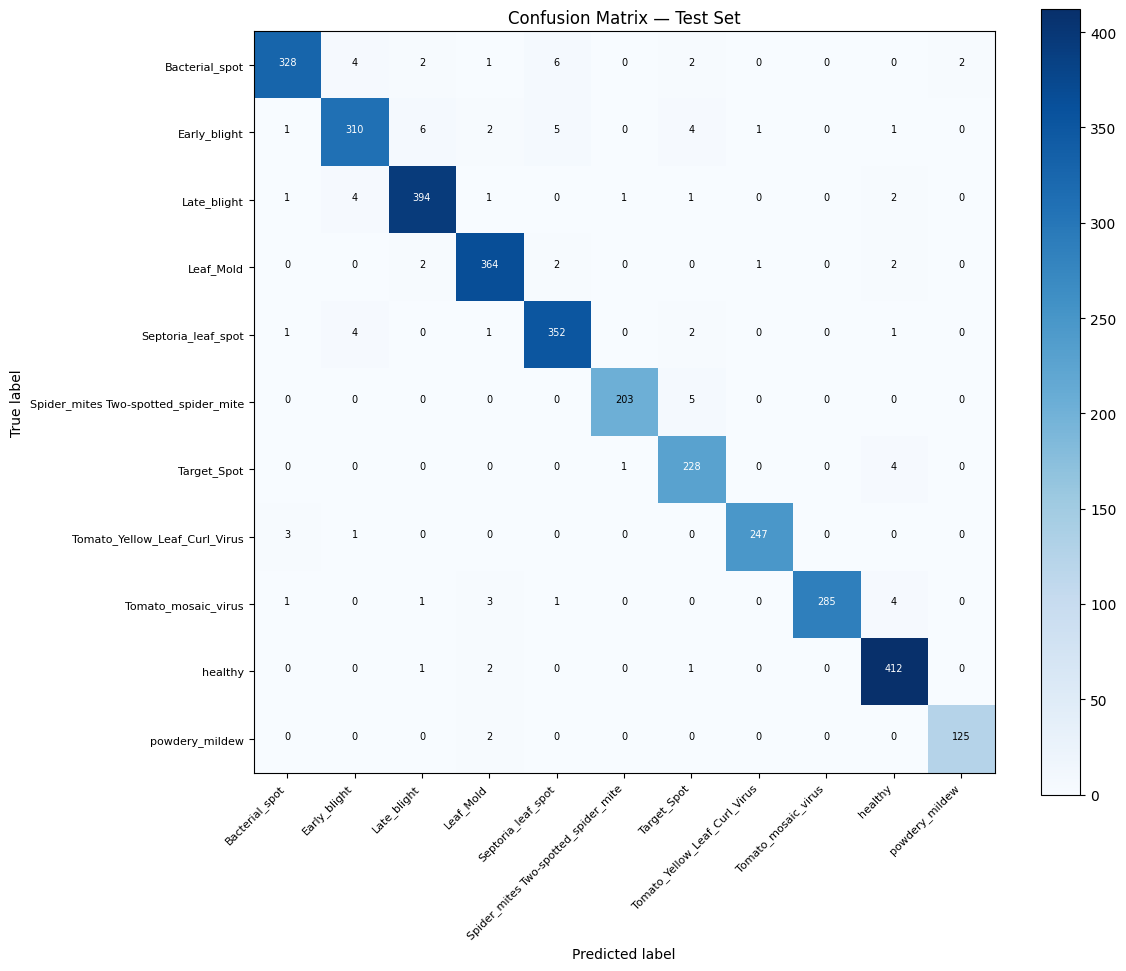

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, class_names, rotation=45, ha="right", fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix — Test Set")

# Annotate cells
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]), horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
model.save("tomato_disease_efficientnetb0.keras")
print("Model saved!")

Model saved!
